In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Cliff Walking
#SARSA vs Q-Learning

GRID_HEIGHT = 4
GRID_WIDTH = 12

# (0,0)縺九ｉ(3,11)縺ｾ縺ｧ縺ｮ繧ｰ繝ｪ繝・ラ繝ｯ繝ｼ繝ｫ繝噂n
Goal = (GRID_HEIGHT - 1, GRID_WIDTH - 1) 
start = (GRID_HEIGHT - 1, 0) 

S = [(y, x) for y in range(GRID_HEIGHT) for x in range(GRID_WIDTH)]
Cliffs = [(GRID_HEIGHT - 1, x) for x in range(1, GRID_WIDTH - 1)]
A = [
    (1,0), # 荳欺n
    (-1,0), # 荳浬n
    (0,1), # 蜿ｳ
    (0,-1) # 蟾ｦ
] 

esp = 0.1
alpha = 0.5
gamma = 1.0

def step(s, a):
    s_next = (s[0] + a[0], s[1] + a[1])
    reward = -1
    
    if s_next not in S:
        s_next = s
        
    if s_next in Cliffs:
        reward = -100
        s_next = start
    
    return s_next, reward

def epsilon_greedy(Q, s, esp):
    a = None
    if np.random.rand() < esp:
        a= np.random.choice(len(A))
    else:
        a = np.argmax(Q[s])
        
    return a

def sarsa(Q_init):
    Q = {s: Q_init[s].copy() for s in S}
    reward_list = []
    
    for episode in range(10000):
        s = start
        a = epsilon_greedy(Q, s, esp)
        total_reward = 0
        
        while s != Goal:
            s_next, r_ = step(s, A[a])
            a_next = epsilon_greedy(Q, s_next, esp)
            
            Q[s][a] += alpha * (r_ + gamma * Q[s_next][a_next] - Q[s][a])
            
            s = s_next
            a = a_next
            total_reward += r_
        
        reward_list.append(total_reward)
        
    return Q, reward_list

def q_learning(Q_init):
    Q = {s: Q_init[s].copy() for s in S}
    reward_list = []
    
    for episode in range(10000):
        s = start
        total_reward = 0
        
        while s != Goal:
            a = epsilon_greedy(Q, s, esp)
            s_next, r_ = step(s, A[a])
            
            Q[s][a] += alpha * (r_ + gamma * np.max(Q[s_next]) - Q[s][a])
            
            s = s_next
            total_reward += r_
        
        reward_list.append(total_reward)
    
    return Q, reward_list

In [14]:
# Q繝・・繝悶Ν縺ｮ蛻晄悄蛹厄ｼ亥・迥ｶ諷九・蜈ｨ陦悟虚繧・縺ｧ蛻晄悄蛹厄ｼ噂n
Q_initial = {s: np.zeros(len(A)) for s in S}

# 蟄ｦ鄙偵・螳溯｡圭n
Q_sarsa, sarsa_rewards = sarsa(Q_initial)
Q_ql, ql_rewards = q_learning(Q_initial)




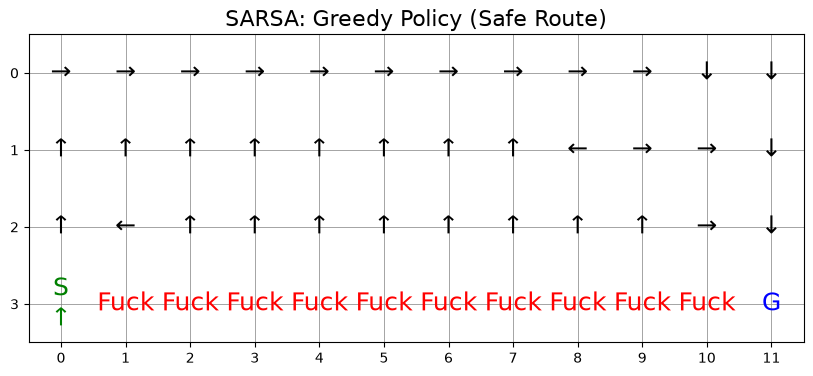

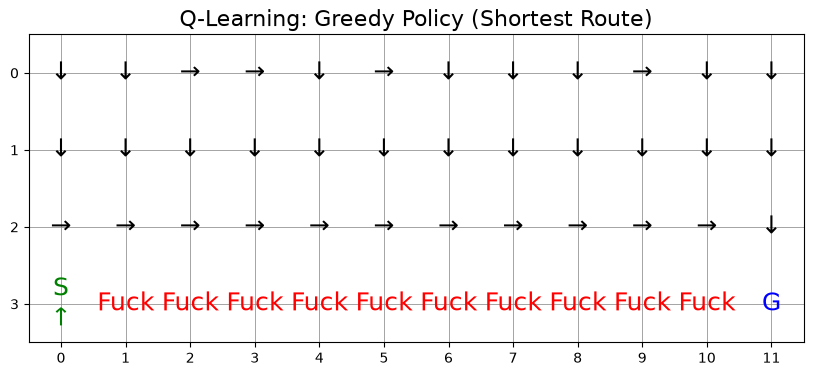

In [15]:
# 矢印の文字化けを修正（上下左右）
arrow_dict = {(1, 0): '↓', (-1, 0): '↑', (0, 1): '→', (0, -1): '←'}

def visualize_policy(Q, title):
    fig, ax = plt.subplots(figsize=(10, 4))
    
    for row in range(GRID_HEIGHT):
        for col in range(GRID_WIDTH):
            s = (row, col)
            
            # マス目の種類によって表示を変える
            if s == Goal:
                text = 'G'
                color = 'blue'
            elif s in Cliffs:
                text = 'Fuck'
                color = 'red'
            else:
                # 貪欲（greedy）に行動を選択
                best_a_idx = np.argmax(Q[s])
                text = arrow_dict[A[best_a_idx]]
                color = 'black'
                
                # スタート地点は S と矢印を両方表示
                if s == start:
                    text = 'S\n' + text
                    color = 'green'

            # テキストをプロット
            ax.text(col, row, text, ha='center', va='center', fontsize=18, color=color)

    ax.set_title(title, fontsize=16)
    
    # グリッドの見た目を整える
    ax.set_xlim(-0.5, GRID_WIDTH - 0.5)
    ax.set_ylim(-0.5, GRID_HEIGHT - 0.5)
    ax.set_xticks(np.arange(GRID_WIDTH))
    ax.set_yticks(np.arange(GRID_HEIGHT))
    ax.grid(color='gray', linestyle='-', linewidth=0.5)
    
    # Y軸を反転させることで、(3,0)のスタート位置を左下にする
    ax.invert_yaxis()
    plt.show()

# SARSAとQ学習の結果をそれぞれ可視化
visualize_policy(Q_sarsa, 'SARSA: Greedy Policy (Safe Route)')
visualize_policy(Q_ql, 'Q-Learning: Greedy Policy (Shortest Route)')

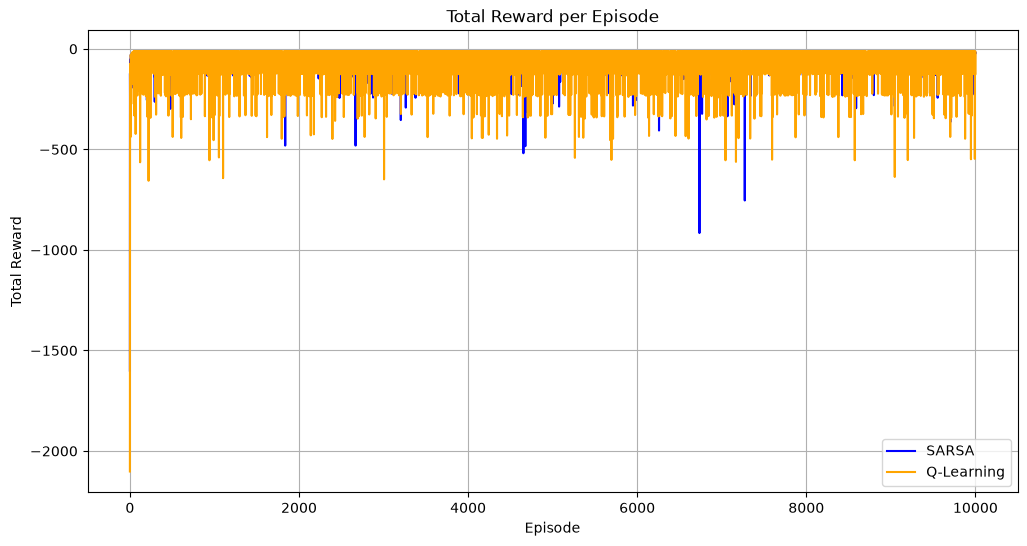

In [16]:
def plot_rewards(sarsa_rewards, ql_rewards):
    plt.figure(figsize=(12, 6))
    plt.plot(sarsa_rewards, label='SARSA', color='blue')
    plt.plot(ql_rewards, label='Q-Learning', color='orange')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.title('Total Reward per Episode')
    plt.legend()
    plt.grid()
    plt.show()
    
# 報酬の推移をプロット
plot_rewards(sarsa_rewards, ql_rewards)

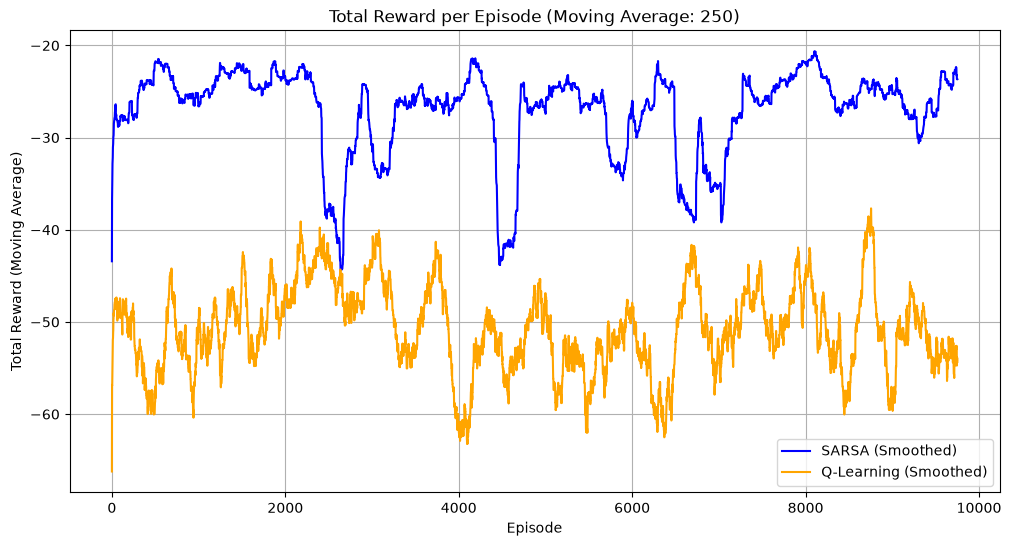

In [22]:
def plot_smoothed_rewards(sarsa_rewards, ql_rewards, window=100):
    # 指定した区間（window）の移動平均を計算
    sarsa_smooth = np.convolve(sarsa_rewards, np.ones(window)/window, mode='valid')
    ql_smooth = np.convolve(ql_rewards, np.ones(window)/window, mode='valid')
    
    plt.figure(figsize=(12, 6))
    plt.plot(sarsa_smooth, label='SARSA (Smoothed)', color='blue')
    plt.plot(ql_smooth, label='Q-Learning (Smoothed)', color='orange')
    
    plt.xlabel('Episode')
    plt.ylabel('Total Reward (Moving Average)')
    plt.title(f'Total Reward per Episode (Moving Average: {window})')
    plt.legend()
    plt.grid()
    plt.show()

# スムージングしてプロットを実行
plot_smoothed_rewards(sarsa_rewards, ql_rewards, window=250)